# How to Identify PDEs

This notebook describes the API for learning PDEs.
There are several approaches for dealing with PDEs in PySINDy:

* Using `PDELibrary` inside a `SINDy` model
* Using `PDELibrary` inside a `WeakSINDy` model
* Reduced-order modeling to convert the ODE to a PDE (potentially using `TrappingSR3`)

We'll demonstrate how to implement these approaches using two systems:
1. The 1D Burgers equation
2. The 2D compressible isothermal flow equations

In [1]:
import copy

import matplotlib.pyplot as plt
import numpy as np

# Some shortcuts to speed up runtime in CI/debugging
if __name__ == "testing":
    import mock_data as data
    import matplotlib

    matplotlib.use("Agg")
    max_iter = 10

else:
    import example_data as data

    max_iter = 1000

from utils import excess_information_loss
from utils import plot_burgers_data_and_derivative
from utils import plot_compressible_data_and_derivative
from utils import plot_field_prediction
from utils import plot_svd_energy
from utils import print_trapping_diagnostics
from utils import burgers_true_coefficients
from utils import compressible_true_coefficients

import pysindy as ps
import sindy_exp

/home/jake/github/sys_id/env13/lib/python3.13/site-packages/dysts/base.py:22: UserWarning: Numba not installed. Falling back to no JIT compilation.
  warnings.warn("Numba not installed. Falling back to no JIT compilation.")


## The data

### Burgers equation

The burger's equation is a simple PDE (here simulated on a 1-D grid)
of advection and diffusion:

$$u_t = -u u_x + \nu u_{xx}$$

Burgers 99% energy rank: 4
Burgers number of SVD modes 4


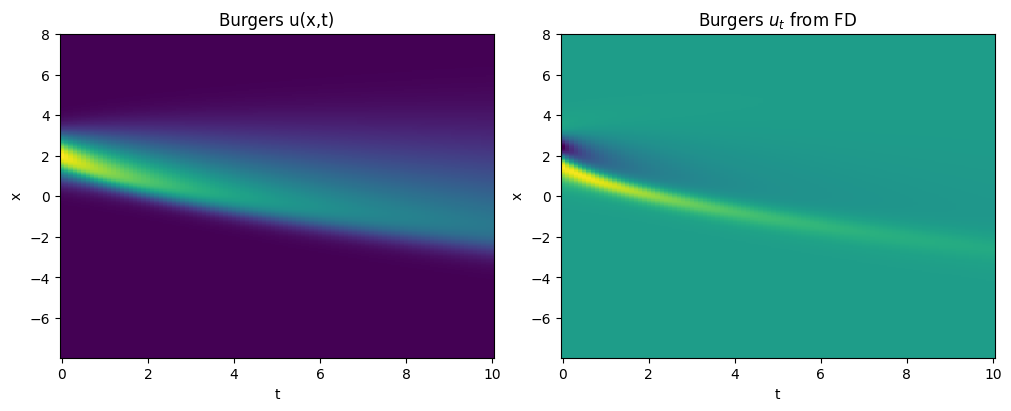

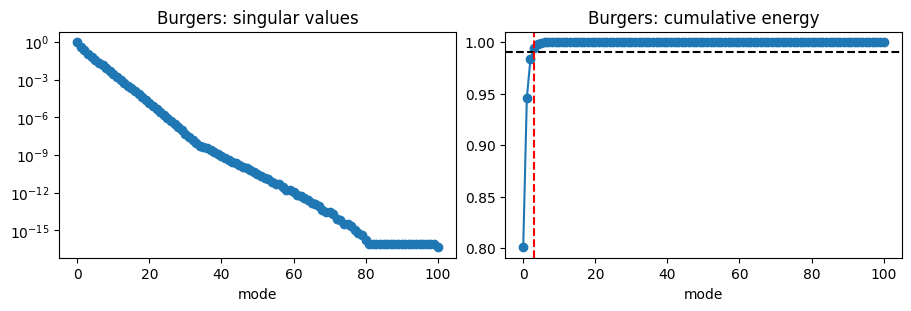

In [2]:
burgers = data.get_burgers_data()
x_burg = burgers["x"]
t_burg = burgers["t"]
u_burg = burgers["u"]
u_dot_burg = burgers["u_dot"]
burg_basis = burgers["svd"].basis
burg_ode_series = burgers["svd"].time_series


plot_burgers_data_and_derivative(x_burg, t_burg, u_burg, u_dot_burg)
plot_svd_energy(burgers["svd"], "Burgers")
print(f"Burgers 99% energy rank: {burgers['svd'].rank_99}")
print(f"Burgers number of SVD modes {burg_basis.shape[-1]}")

### Compressible, Isothermal Flow

A more challenging problem from fluid dynamics, on a 2D grid.
Advection and diffusion of a 2D velocity field, with variable density.
$$u_t = -u u_x - v u_y - p_x + \nu (u_{xx} + u_{yy})$$
$$v_t = -u v_x - v v_y - p_y + \nu (v_{xx} + v_{yy})$$
$$\rho_t = -u \rho_x - v \rho_y - \rho (u_x + v_y)$$

Compressible number of SVD modes 2
Compressible 99% energy rank: 2


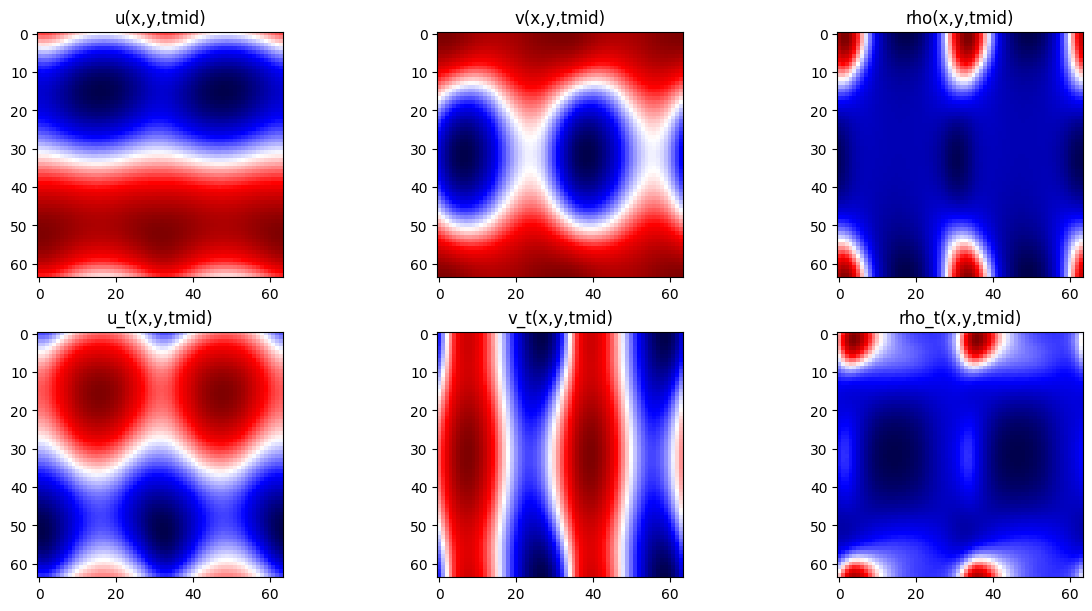

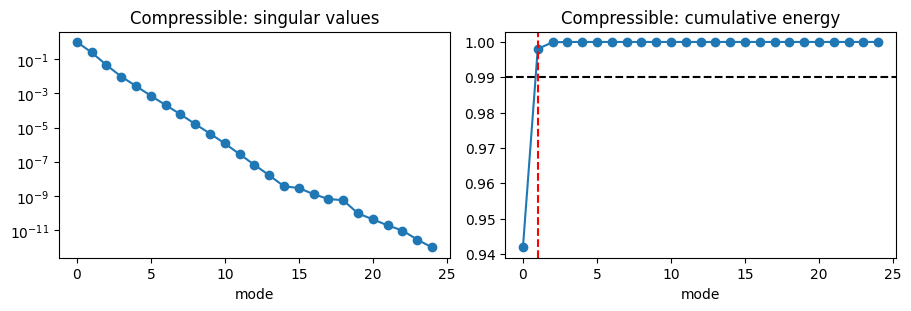

In [3]:
nx = 64
nt = 25
compressible = data.get_compressible_data(nx, nt)
x_fluid = np.stack(
    np.meshgrid(compressible["x"], compressible["y"], indexing="ij"), axis=-1
)
t_fluid = compressible["t"]
u_fluid = compressible["u"]
u_dot_fluid = compressible["u_dot"]
fluid_basis = compressible["svd"].basis
fluid_ode_series = compressible["svd"].time_series
print(f"Compressible number of SVD modes {fluid_basis.shape[-1]}")

plot_compressible_data_and_derivative(t_fluid, u_fluid, u_dot_fluid)
plot_svd_energy(compressible["svd"], "Compressible")
print(f"Compressible 99% energy rank: {compressible['svd'].rank_99}")

## Building and fitting the models

### PDEFind

PDEFIND is implemented merely as a SINDy model with a `PDELibrary`.
This may change in the future, as it requires passing the spatial grid along
with the data-independent initialization arguments.  As a consequence, it
will not work for multiple trajectories on different grids.

`PDELibrary` calls pysindy's differentiation methods to compute spatial derivatives.
A consequence of this is that the differentiation/smoothing is inherently 1-D.
By default, it computes all derivatives up to the specified order,
but this can be customized by passing `multiindices`.

In [4]:
pde_lib_burg = ps.PDELibrary(derivative_order=2, spatial_grid=x_burg)
poly_lib = ps.PolynomialLibrary(degree=2, include_bias=False)
bias_lib = ps.PolynomialLibrary(degree=0, include_bias=True)
burg_lib = bias_lib + poly_lib + pde_lib_burg + poly_lib * pde_lib_burg
reg_wt = ps.SR3.calculate_l0_weight(0.1, 1)
opt_burg = ps.SR3(reg_weight_lam=reg_wt, regularizer="l0", max_iter=max_iter)
pdefind_burg = ps.SINDy(feature_library=burg_lib, optimizer=opt_burg)

pdefind_burg.fit(u_burg, t=t_burg, feature_names=["u"])
print("PDE-FIND Burgers model:")
pdefind_burg.print()

pde_lib_fluid = ps.PDELibrary(derivative_order=2, spatial_grid=x_fluid)
inv_lib = ps.CustomLibrary([lambda x: 1 / x], [lambda x: f"{x}" + "**-1"])
bias_lib = ps.PolynomialLibrary(degree=0, include_bias=True)
reg_wt = ps.SR3.calculate_l0_weight(0.1, 1)
opt_fluid = ps.SR3(reg_weight_lam=reg_wt, regularizer="l0", max_iter=max_iter)
fluid_lib = bias_lib + inv_lib + pde_lib_fluid + inv_lib * pde_lib_fluid
pdefind_fluid = ps.SINDy(feature_library=fluid_lib, optimizer=opt_fluid)

# Add some noise to improve condition number
rng = np.random.default_rng(0)
u_fluid += rng.normal(scale=1e-8, size=u_fluid.shape)
pdefind_fluid.fit(u_fluid, t=t_fluid, feature_names=["u", "v", "p"])
print("\nPDE-FIND Compressible model:")
pdefind_fluid.print()

PDE-FIND Burgers model:
(u)' =  0.100 u_11 + -1.002 u u_1



PDE-FIND Compressible model:
(u)' = -0.207 1 +  1.460 u_2 +  1.218 v_2 + -0.118 p_2 + -1.125 u_22 +  0.201 v_22 +  0.204 u_1 + -0.903 v_1 +  0.402 p_1 +  2.272 u_12 +  0.562 v_12 + -0.134 p_12 + -0.327 u_11 + -0.907 v_11 +  0.159 p_11 + -0.210 p**-1 u_2 + -1.098 p**-1 v_2 + -0.179 p**-1 p_2 +  2.085 p**-1 u_22 + -0.933 p**-1 v_1 + -1.381 p**-1 p_1 + -1.957 p**-1 u_12 + -0.430 p**-1 v_12 +  0.611 p**-1 u_11 +  0.892 p**-1 v_11 + -0.144 p**-1 p_11
(v)' = -0.205 p**-1 + -4.870 u_2 +  0.402 v_2 +  0.766 p_2 + -0.487 u_22 + -0.834 v_22 +  0.492 u_1 +  1.861 v_1 + -0.132 p_1 +  2.011 u_12 +  0.130 v_12 +  0.618 u_11 + -0.801 v_11 +  0.181 p_11 +  4.102 p**-1 u_2 + -0.566 p**-1 v_2 + -1.735 p**-1 p_2 +  0.656 p**-1 u_22 +  1.693 p**-1 v_22 + -1.477 p**-1 v_1 + -0.110 p**-1 p_1 + -1.605 p**-1 u_12 + -0.159 p**-1 v_12 + -0.492 p**-1 u_11 +  1.316 p**-1 v_11 + -0.265 p**-1 p_11
(p)' = -0.512 1 +  0.353 p**-1 +  0.910 u_2 + -0.153 v_2 + -0.402 p_2 + -1.650 u_22 +  0.176 v_22 + -0.477 u_1 +  2.31

### Weak SINDy

Weak SINDy replaces pointwise derivative matching with integral penalties
over randomly sampled spatiotemporal subdomains.
This weak formulation suppresses high-frequency noise and avoids
explicitly computing unstable high-order derivatives at each grid point.

WeakSINDy can also work with ODEs - in such a case, the only change required is to
not include a PDELibrary.
WeakSINDy's API is very similar to regular `SINDy`, treating an ODE's time points
as merely a lower-dimensional spatiotemporal grid.  The shape of the spatiotemporal
field should reflect the shape of the data.

In [5]:
if __name__ == "testing":
    max_subdomains = 10
else:
    max_subdomains = 1000

st_burg = np.stack(np.meshgrid(x_burg, t_burg, indexing="ij"), axis=-1)
opt_burg2 = copy.copy(opt_burg)
weak_burg = ps.WeakSINDy(
    feature_library=burg_lib, optimizer=opt_burg2, n_subdomains=min(300, max_subdomains)
)
weak_burg.fit(u_burg, st_grids=st_burg, feature_names=["u"])
print("WeakSINDy Burgers model:")
weak_burg.print()

st_fluid = np.stack(
    np.meshgrid(compressible["x"], compressible["y"], compressible["t"], indexing="ij"),
    axis=-1,
)
opt_fluid2 = copy.copy(opt_fluid)
weak_fluid = ps.WeakSINDy(
    feature_library=fluid_lib,
    optimizer=opt_fluid2,
    n_subdomains=min(1000, max_subdomains),
)
weak_fluid.fit(u_fluid, st_grids=st_fluid, feature_names=["u", "v", "p"])
print("WeakSINDy Compressible model:")
weak_fluid.print()

WeakSINDy Burgers model:
(u)' = -0.941 u_1 u


WeakSINDy Compressible model:
(u)' = -0.146 1 +  3.777 u_2 +  0.805 v_2 + -0.496 p_2 + -0.617 u_22 +  0.505 v_22 + -0.811 u_1 + -1.959 v_1 +  1.025 p_1 +  0.701 u_12 + -0.341 v_12 +  0.221 p_12 + -0.286 u_11 +  0.882 v_11 + -0.137 p_11 + -2.523 u_2 p**-1 + -0.698 v_2 p**-1 +  0.323 p_2 p**-1 +  1.648 u_22 p**-1 + -0.302 v_22 p**-1 +  0.829 u_1 p**-1 + -0.204 v_1 u**-1 + -0.404 v_1 p**-1 +  0.171 p_1 u**-1 + -1.875 p_1 p**-1 +  0.139 u_12 u**-1 + -0.833 u_12 p**-1 + -0.295 v_12 u**-1 +  0.741 v_12 p**-1 + -0.388 p_12 p**-1 +  0.426 u_11 p**-1 + -0.697 v_11 p**-1 +  0.146 p_11 p**-1
(v)' = -0.111 1 + -0.143 p**-1 + -6.935 u_2 +  1.372 v_2 +  0.747 p_2 + -0.967 u_22 + -1.095 v_22 +  1.034 u_1 +  0.519 v_1 +  4.431 u_12 + -0.444 v_12 + -0.250 p_12 +  0.281 u_11 + -1.192 v_11 +  0.167 p_11 +  5.047 u_2 p**-1 + -1.048 v_2 p**-1 + -1.470 p_2 p**-1 +  0.764 u_22 p**-1 +  1.773 v_22 p**-1 + -0.445 u_1 p**-1 +  0.145 v_1 u**-1 + -0.157 p_1 p**-1 + -3.935 u_12 p**-1 + -0.203 v_12 u**-1 +  0.565 v

/home/jake/github/sys_id/sub/pysindy/pysindy/optimizers/sr3.py:374: ConvergenceWarning: SR3 did not converge after 1000 iterations.
  warnings.warn(


### Regular SINDy on reduced order model, using Trapping

`TrappingSR3` is a constrained SR3 variant for quadratic reduced-order models.
It allows effective nonlinearities but encourages globally/locally-bounded
dynamics.  This is useful to allow stable long-time simulations, both for ODEs
and reduced-order models of PDEs.

Its implementation leaves a few things to be desired.  Firstly, it does not work
for `DiscreteSINDy`.  Secondly, the associated feature library must be quadratic
(`PolynomialLibrary` with degree 2).
Thirdly, by inheriting from `ConstrainedSR3`, it requires certain data-dependent
variables and knowledge of the feature library to be passed at initialization.
These idiosyncratic parameters are given a leading underscore.

In [6]:
b_rank = min(3, burgers["svd"].rank_99)

poly_lib = ps.PolynomialLibrary(degree=2, include_bias=True)
trap_opt_burg = ps.TrappingSR3(
    _n_tgts=b_rank,
    _include_bias=True,
    beta=1e-2,
    max_iter=max_iter,
    eta=1e-2,
    reg_weight_lam=1e-1,
    regularizer="l2",
    verbose=True,
)
trap_burg = ps.SINDy(feature_library=poly_lib, optimizer=trap_opt_burg)

burg_modes = burg_basis[:, :b_rank]
burg_y = burg_ode_series[:, :b_rank]
trap_burg.fit(burg_y, t=t_burg)
print("Trapping ROM Burgers model:")
trap_burg.print()


c_rank = min(5, compressible["svd"].rank_99)
poly_lib = ps.PolynomialLibrary(degree=2, include_bias=True)
trap_opt_fluid = ps.TrappingSR3(
    _n_tgts=c_rank,
    _include_bias=True,
    beta=1e-2,
    max_iter=max_iter,
    eta=1e-2,
    reg_weight_lam=1e-1,
    regularizer="l2",
    verbose=True,
)
trap_fluid = ps.SINDy(feature_library=poly_lib, optimizer=trap_opt_fluid)

fluid_modes = fluid_basis[:, :c_rank]
fluid_y = fluid_ode_series[:, :c_rank]
trap_fluid.fit(fluid_y, t=t_fluid)
print("\nTrapping ROM Compressible model:")
trap_fluid.print()

/home/jake/github/sys_id/sub/pysindy/pysindy/optimizers/trapping_sr3.py:316: UserWarning: alpha was not set, so defaulting to alpha = 1e20 which is solarge that the ||Qijk|| term in the optimization will be essentially ignored.
  warnings.warn(


 Iter ... |y-Xw|^2 ... |Pw-A|^2/eta ... |w|_1 ... |Qijk|/a ... |Qijk+...|/b ...   Total:
    0 ... 1.475e+00 ... 1.156e-01 ... 3.67e-01 ... 1.39e-22 ... 4.77e-29 ... 1.96e+00


  100 ... 5.288e+00 ... 4.786e-30 ... 1.94e+00 ... 2.91e-21 ... 2.92e-28 ... 7.23e+00


Trapping ROM Burgers model:
(x0)' = -2.939 1 + -1.078 x0 +  1.172 x1 + -0.886 x2 +  0.310 x0 x1 + -0.108 x0 x2 + -0.269 x1^2 +  0.078 x1 x2 +  0.059 x2^2
(x1)' = -1.348 1 + -1.505 x0 +  0.721 x1 + -0.114 x2 + -0.310 x0^2 +  0.269 x0 x1 + -0.260 x0 x2 +  0.372 x1 x2 + -0.176 x2^2
(x2)' =  4.190 1 +  1.486 x0 + -0.230 x1 + -0.609 x2 +  0.108 x0^2 +  0.183 x0 x1 + -0.059 x0 x2 + -0.372 x1^2 +  0.176 x1 x2
 Iter ... |y-Xw|^2 ... |Pw-A|^2/eta ... |w|_1 ... |Qijk|/a ... |Qijk+...|/b ...   Total:
    0 ... 2.265e+01 ... 4.191e-29 ... 3.00e+00 ... 1.89e-23 ... 9.11e-22 ... 2.56e+01

Trapping ROM Compressible model:
(x0)' = -10.072 1 + -0.608 x0 +  4.760 x1 +  0.066 x0 x1 + -0.014 x1^2
(x1)' = -14.538 1 + -7.102 x0 + -4.478 x1 + -0.066 x0^2 +  0.014 x0 x1


/home/jake/github/sys_id/sub/pysindy/pysindy/optimizers/trapping_sr3.py:316: UserWarning: alpha was not set, so defaulting to alpha = 1e20 which is solarge that the ||Qijk|| term in the optimization will be essentially ignored.
  warnings.warn(


## Evaluating the models

PDEs can mostly be evaluated the same ways as any SINDy model, as described in the
`model_evaluation tutorial <./tutorial_2/example.ipynp>`_ .

### Coefficients

Coefficient metrics require knowing the true system.  Thus, we only compute them
for PDEFIND and WeakSINDy, not Trapping SINDy on the reduced order model.

#### Burgers equation

Burgers PDE-FIND coefficient MAE: 0.00023270321111111238
Burgers Weak-SINDy coefficient MAE: 0.017651242255555553


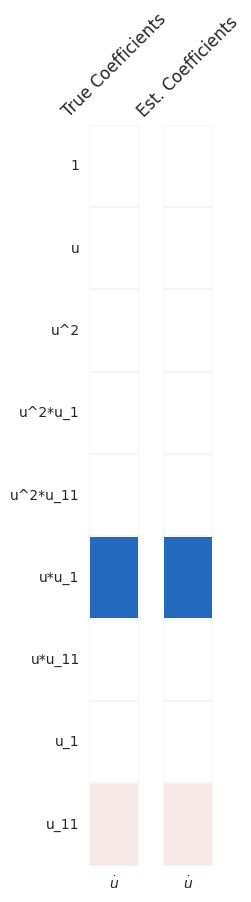

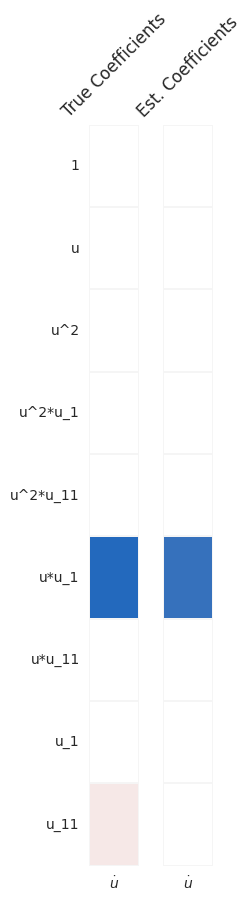

In [7]:
b_true = burgers_true_coefficients(["u"])
b_true, burg_pdefind_coeff = sindy_exp._utils.unionize_coeff_dicts(pdefind_burg, b_true)
b_true, burg_weak_coeff = sindy_exp._utils.unionize_coeff_dicts(weak_burg, b_true)
burg_pdefind_mae = sindy_exp.coeff_metrics(burg_pdefind_coeff, b_true)["coeff_mae"]
burg_weak_mae = sindy_exp.coeff_metrics(burg_weak_coeff, b_true)["coeff_mae"]
print("Burgers PDE-FIND coefficient MAE:", burg_pdefind_mae)
print("Burgers Weak-SINDy coefficient MAE:", burg_weak_mae)
sindy_exp.compare_coefficient_plots_from_dicts(
    burg_pdefind_coeff, b_true, input_features=["u"]
)
sindy_exp.compare_coefficient_plots_from_dicts(
    burg_weak_coeff, b_true, input_features=["u"]
)

#### Compressible isothermal flow

Compressible PDE-FIND coefficient MAE: 0.3408853903972222
Compressible Weak-SINDy coefficient MAE: 0.3942731887152778


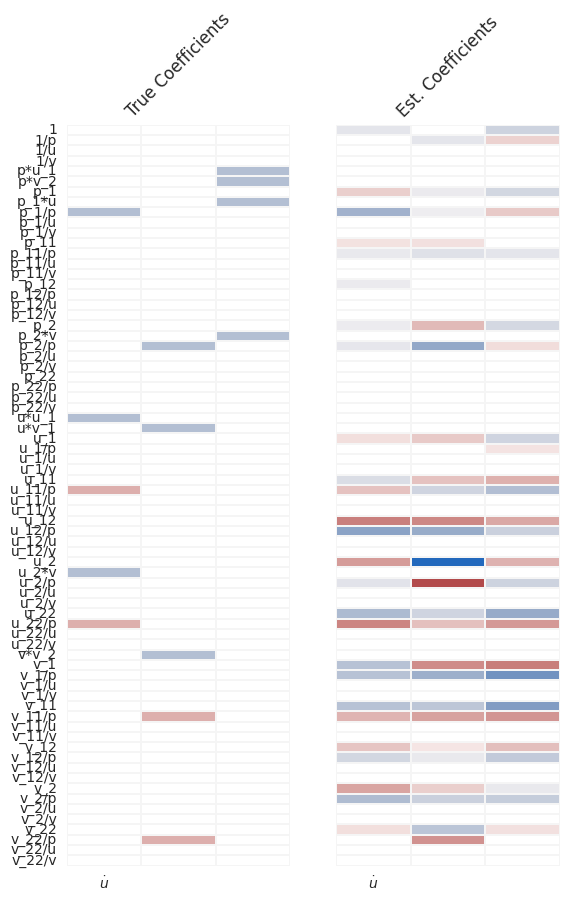

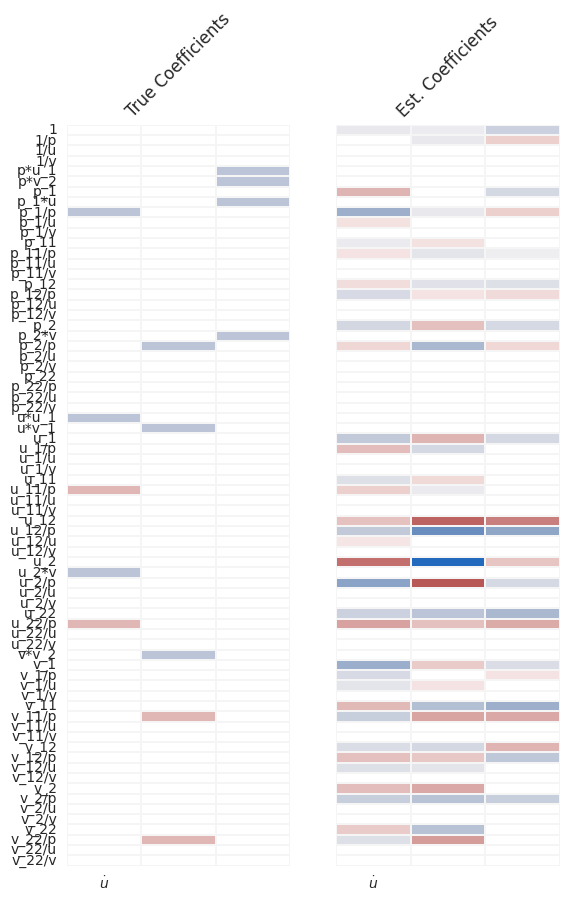

In [8]:
c_true = compressible_true_coefficients(["u", "v", "p"], 1, 1)
c_true, fluid_pdefind_coeff = sindy_exp._utils.unionize_coeff_dicts(
    pdefind_fluid, c_true
)
c_true, fluid_weak_coeff = sindy_exp._utils.unionize_coeff_dicts(weak_fluid, c_true)
fluid_pdefind_mae = sindy_exp.coeff_metrics(fluid_pdefind_coeff, c_true)["coeff_mae"]
fluid_weak_mae = sindy_exp.coeff_metrics(fluid_weak_coeff, c_true)["coeff_mae"]
print("Compressible PDE-FIND coefficient MAE:", fluid_pdefind_mae)
print("Compressible Weak-SINDy coefficient MAE:", fluid_weak_mae)
sindy_exp.compare_coefficient_plots_from_dicts(
    fluid_pdefind_coeff, c_true, input_features=["u"]
)
sindy_exp.compare_coefficient_plots_from_dicts(
    fluid_weak_coeff, c_true, input_features=["u"]
)

### Predictions

#### Burgers equation

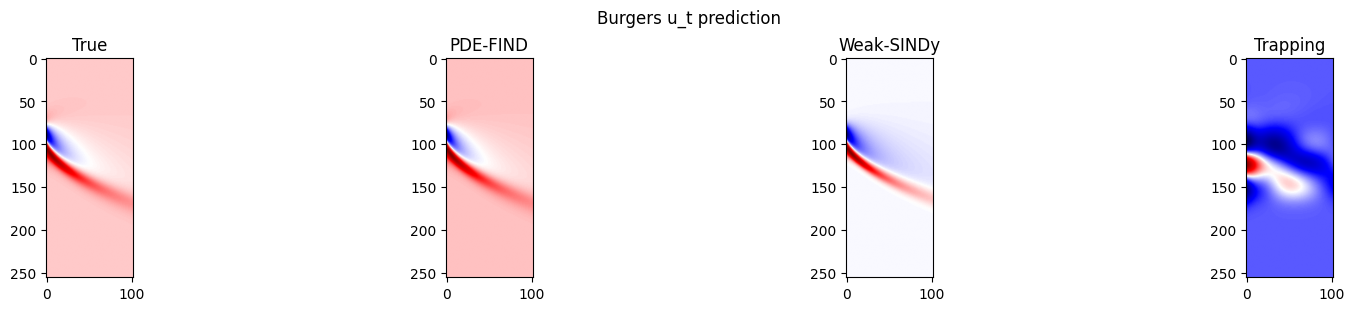

In [9]:


mid = len(burgers["t"]) // 2
pdefind_b_dot = pdefind_burg.predict(u_burg)
weak_b_dot = weak_burg.predict(u_burg)
trap_b_dot = (burg_modes @ trap_burg.predict(burg_y).T)[..., np.newaxis]
plot_field_prediction(
    u_dot_burg,
    {
        "PDE-FIND": pdefind_b_dot,
        "Weak-SINDy": weak_b_dot,
        "Trapping": trap_b_dot,
    },
    "Burgers u_t prediction",
)

#### Compressible isothermal flow

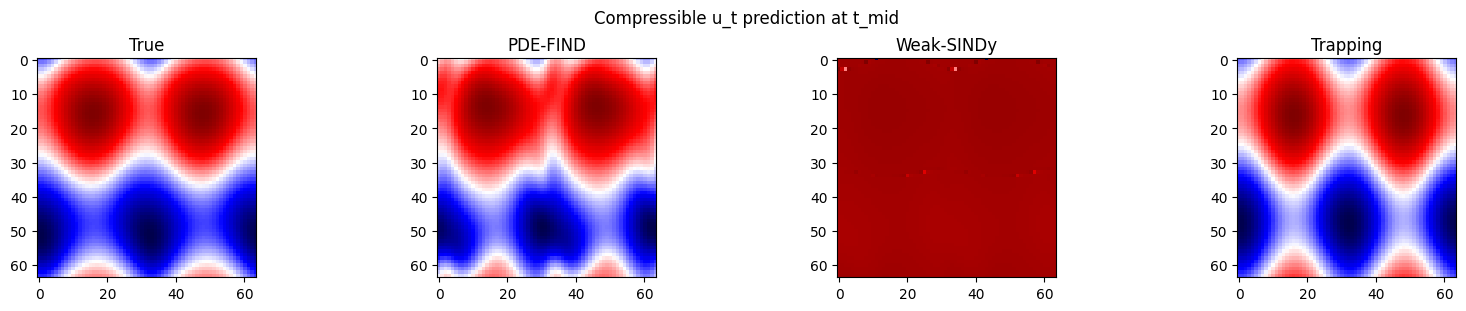

In [10]:
mid = len(compressible["t"]) // 2
pdefind_c_dot = pdefind_fluid.predict(compressible["u"])
weak_c_dot = weak_fluid.predict(compressible["u"])
trap_c_dot = fluid_modes @ trap_fluid.predict(fluid_y).T
trap_c_dot = np.transpose(np.reshape(trap_c_dot, (nx, nx, 3, nt)), (0, 1, 3, 2))
plot_field_prediction(
    compressible["u_dot"][:, :, mid, 0],
    {
        "PDE-FIND": pdefind_c_dot[:, :, mid, 0],
        "Weak-SINDy": weak_c_dot[:, :, mid, 0],
        "Trapping": trap_c_dot[:, :, mid, 0],
    },
    "Compressible u_t prediction at t_mid",
)

### Simulation

Generic PDE simulation is tricky, so `SINDy.simulate()` only works for ODEs.
Thus, here we only simulate the Trapping reduced order ODE.

There are more specific ways to evaluate Trapping.  For more thorough evaluation
metrics, see the trapping research notebooks.

Burgers ROM excess information loss: 6.473
Compressible ROM excess information loss: 0.224
Burgers trapping eig max (last): -1.7367e-01
Compressible trapping eig max (last): -3.3909e-01


Text(0.5, 1.0, 'Compressible ROM phase (first mode)')

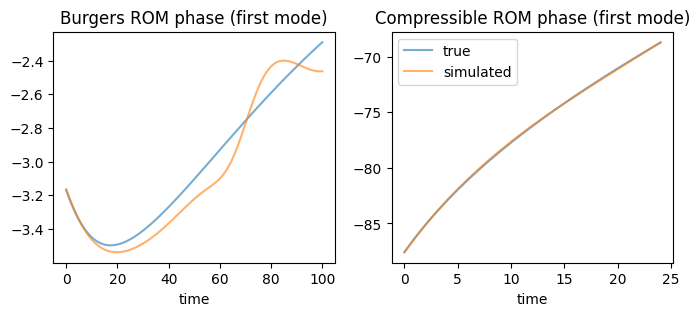

In [11]:
b_true_a = burg_y
c_true_a = fluid_y
b_sim_a = trap_burg.simulate(b_true_a[0], burgers["t"])
c_sim_a = trap_fluid.simulate(c_true_a[0], compressible["t"])
print(
    f"Burgers ROM excess information loss: {excess_information_loss(b_true_a, b_sim_a):.3f}"
)
print(
    f"Compressible ROM excess information loss: {excess_information_loss(c_true_a, c_sim_a):.3f}"
)
print_trapping_diagnostics(trap_burg, "Burgers")
print_trapping_diagnostics(trap_fluid, "Compressible")
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(b_true_a[:, 0], alpha=0.6, label="true")
plt.plot(b_sim_a[:, 0], alpha=0.6, label="simulated")
plt.xlabel("time")
plt.title("Burgers ROM phase (first mode)")
plt.subplot(1, 2, 2)
plt.plot(c_true_a[:, 0], alpha=0.6, label="true")
plt.plot(c_sim_a[:, 0], alpha=0.6, label="simulated")
plt.xlabel("time")
plt.legend()
plt.title("Compressible ROM phase (first mode)")